# Reporte de ejemplos — Intervalos de confianza

**Diplomado en Técnicas Estadísticas y Minería de Datos — Unidad 2**

**Autor:** yagoraulhuertaorozco@gmail.com

**Fecha:** 29 de septiembre de 2026

---

<a id="introduccion"></a>
## 1. Introducción

Este cuaderno recorre los cuatro ejercicios del archivo `08_Ejercicios_intervalos_de_confianza.pdf` sobre **intervalos de confianza** para la media de una población normal: el caso con varianza conocida (Ejercicio 5.4), el cálculo del tamaño de muestra requerido (Ejemplo 5.5), el caso con varianza desconocida (Ejercicio 5.6) y el intervalo para la diferencia de medias de dos poblaciones con varianzas iguales (Ejercicio 5.7).

Los ejercicios son:

- **Ejercicio 5.4 (IC con $\sigma$ conocida)** — 16 cajas de cereal, $\sigma = 5$ g, intervalos al 90, 95 y 99 %.
- **Ejemplo 5.5 (Tamaño de muestra)** — población normal con $\sigma^2 = 10$, $\epsilon = 1$, $P = 0.90$.
- **Ejercicio 5.6 (IC con $\sigma$ desconocida)** — mismos 16 pesos, intervalos al 90, 95 y 99 %.
- **Ejercicio 5.7 (IC para $\mu_1 - \mu_2$, varianzas iguales)** — contadores vs. administradores al 90 %.

<a id="indice"></a>
## 2. Índice

- [1. Introducción](#introduccion)
- [2. Índice](#indice)
- [3. Configuración inicial](#setup)
- [4. Ejercicio 5.4 — IC con $\sigma$ conocida](#ej54)
- [5. Ejemplo 5.5 — Tamaño de muestra](#ej55)
- [6. Ejercicio 5.6 — IC con $\sigma$ desconocida](#ej56)
- [7. Ejercicio 5.7 — IC para $\mu_1 - \mu_2$](#ej57)
- [8. Conclusiones](#conclusiones)

<a id="setup"></a>
## 3. Configuración inicial

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sympy as sp
from scipy import stats as st

sp.init_printing(use_latex="mathjax")

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.family": "sans-serif",
})

PALETTE_CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
COLOR_HIGHLIGHT = "#e34948"
COLOR_MEAN = "#e34948"
COLOR_CONOCIDA = PALETTE_CATEGORICAL[0]   # azul
COLOR_DESCONOCIDA = PALETTE_CATEGORICAL[1]  # naranja

<a id="ej54"></a>
## 4. Ejercicio 5.4 — IC con $\sigma$ conocida

Los pesos en gramos del contenido de 16 cajas de cereal seleccionadas aleatoriamente de un proceso de llenado son:

$$
506,\ 508,\ 499,\ 503,\ 504,\ 510,\ 497,\ 512,\ 514,\ 505,\ 493,\ 496,\ 506,\ 502,\ 509,\ 496.
$$

Se asume que cada caja es $N(\mu, \sigma^2)$ con $\sigma = 5$ g (desviación **conocida**). Para una muestra aleatoria de tamaño $n$ se cumple

$$
Z = \frac{\bar X - \mu}{\sigma/\sqrt{n}} \sim N(0, 1),
$$

por lo que un IC bilateral al nivel $1 - \alpha$ es

$$
\bar X \pm z_{\alpha/2}\,\frac{\sigma}{\sqrt{n}}.
$$

Pedimos los intervalos al 90, 95 y 99 %.

In [2]:
# Datos y parametros del Ejercicio 5.4
datos_cereal = np.array([
    506, 508, 499, 503, 504, 510, 497, 512,
    514, 505, 493, 496, 506, 502, 509, 496,
])
n_cereal = len(datos_cereal)
media_cereal = float(datos_cereal.mean())
sigma_cereal = 5.0  # conocida

print(f"n            = {n_cereal}")
print(f"media muestral = {media_cereal:.6f} g")
print(f"sigma (conocida) = {sigma_cereal} g")

n            = 16
media muestral = 503.750000 g
sigma (conocida) = 5.0 g


In [3]:
# Derivacion simbolica: mostramos que el IC X_bar +/- z * sigma / sqrt(n)
# se despeja directamente de la definicion de cuantil de la normal estandar.
n_s, sigma_s, z_s, alpha_s, xbar_s = sp.symbols(
    "n sigma z alpha xbar", positive=True, real=True
)

margen_sigma = z_s * sigma_s / sp.sqrt(n_s)
lim_inf = xbar_s - margen_sigma
lim_sup = xbar_s + margen_sigma

print("Formula simbolica del IC:")
display(sp.Eq(sp.Symbol("L_inf"), lim_inf))
display(sp.Eq(sp.Symbol("L_sup"), lim_sup))

Formula simbolica del IC:


            σ⋅z
L_inf = x̅ - ───
            √n 

           σ⋅z
Lₛᵤₚ = x̅ + ───
           √n 

In [4]:
# Calculo del IC para los tres niveles de confianza.
confianzas = [0.90, 0.95, 0.99]

ic_54 = {}
for c in confianzas:
    z = float(st.norm.ppf(1 - (1 - c) / 2))
    margen = z * sigma_cereal / math.sqrt(n_cereal)
    ic_54[c] = {
        "z": z,
        "margen": margen,
        "li": media_cereal - margen,
        "ls": media_cereal + margen,
        "ancho": 2 * margen,
    }

print(f"{'conf':>6} {'z':>8} {'margen':>10} {'lim_inf':>12} {'lim_sup':>12}")
for c, d in ic_54.items():
    print(
        f"{c:>6.2f} {d['z']:>8.4f} {d['margen']:>10.4f} "
        f"{d['li']:>12.4f} {d['ls']:>12.4f}"
    )

  conf        z     margen      lim_inf      lim_sup
  0.90   1.6449     2.0561     501.6939     505.8061
  0.95   1.9600     2.4500     501.3000     506.2000
  0.99   2.5758     3.2198     500.5302     506.9698


### 4.1 Comparativa visual con el caso $\sigma$ desconocida

Para anticipar el Ejercicio 5.6, calculamos también los IC con $\sigma$ desconocida (usando $s$ y $t_{n-1}$). El gráfico de tipo *forest plot* superpone ambos casos para los tres niveles de confianza: las **líneas continuas** corresponden al IC con $\sigma$ conocida (Ej. 5.4) y las **líneas punteadas** al IC con $\sigma$ estimada (Ej. 5.6, calculadas más adelante).

In [5]:
# Calculamos IC con sigma desconocida (mismos datos) para el grafico
# comparativo. Usamos s = sqrt(ss/(n-1)) y la distribucion t de Student.
s_cereal = float(datos_cereal.std(ddof=1))
gl_cereal = n_cereal - 1

ic_56_preview = {}
for c in confianzas:
    tcrit = float(st.t.ppf(1 - (1 - c) / 2, df=gl_cereal))
    margen = tcrit * s_cereal / math.sqrt(n_cereal)
    ic_56_preview[c] = {
        "t": tcrit,
        "margen": margen,
        "li": media_cereal - margen,
        "ls": media_cereal + margen,
        "ancho": 2 * margen,
    }

print(f"{'conf':>6} {'t':>8} {'margen':>10} {'lim_inf':>12} {'lim_sup':>12}")
for c, d in ic_56_preview.items():
    print(
        f"{c:>6.2f} {d['t']:>8.4f} {d['margen']:>10.4f} "
        f"{d['li']:>12.4f} {d['ls']:>12.4f}"
    )

  conf        t     margen      lim_inf      lim_sup
  0.90   1.7531     2.7182     501.0318     506.4682
  0.95   2.1314     3.3049     500.4451     507.0549
  0.99   2.9467     4.5690     499.1810     508.3190


<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_53011/3170817545.py:31: SyntaxWarning: invalid escape sequence '\o'
  label=f"$\overline{{X}}$ = {media_cereal:.3f} g", zorder=1,
/tmp/ipykernel_53011/3170817545.py:39: SyntaxWarning: invalid escape sequence '\m'
  "Ej. 5.4 vs. Ej. 5.6 — IC para $\mu$ con $\sigma$ "
/tmp/ipykernel_53011/3170817545.py:45: SyntaxWarning: invalid escape sequence '\s'
  label="$\sigma$ conocida (z)"),
/tmp/ipykernel_53011/3170817545.py:47: SyntaxWarning: invalid escape sequence '\s'
  linest

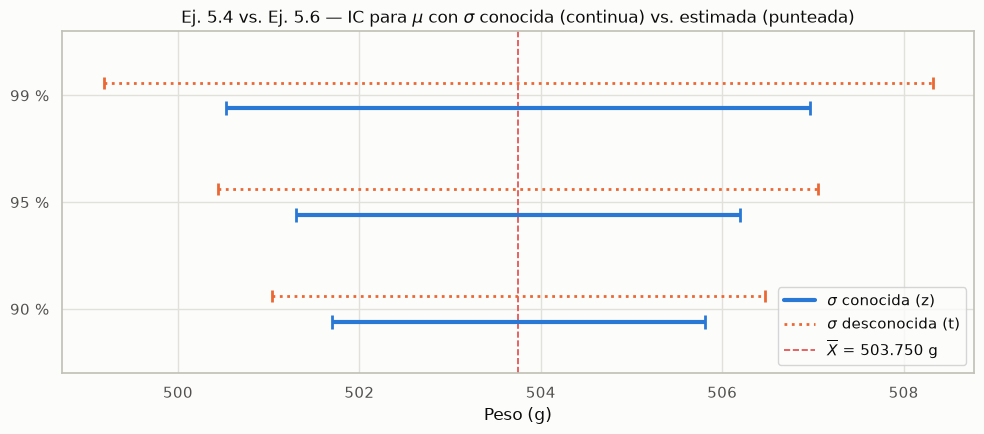

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
y_pos = np.arange(len(confianzas))

# Lineas continuas: sigma conocida (Ej 5.4)
for i, c in enumerate(confianzas):
    d = ic_54[c]
    ax.hlines(
        y=i - 0.12, xmin=d["li"], xmax=d["ls"],
        color=COLOR_CONOCIDA, linewidth=3, zorder=2,
    )
    ax.plot(
        [d["li"], d["ls"]], [i - 0.12, i - 0.12],
        "|", color=COLOR_CONOCIDA, markersize=10, markeredgewidth=2,
    )

# Lineas punteadas: sigma desconocida (Ej 5.6)
for i, c in enumerate(confianzas):
    d = ic_56_preview[c]
    ax.hlines(
        y=i + 0.12, xmin=d["li"], xmax=d["ls"],
        color=COLOR_DESCONOCIDA, linewidth=2, linestyles=":", zorder=2,
    )
    ax.plot(
        [d["li"], d["ls"]], [i + 0.12, i + 0.12],
        "|", color=COLOR_DESCONOCIDA, markersize=8, markeredgewidth=2,
    )

# Media muestral
ax.axvline(
    media_cereal, color=COLOR_MEAN, linestyle="--", linewidth=1.2,
    label=f"$\overline{{X}}$ = {media_cereal:.3f} g", zorder=1,
)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{int(c*100)} %" for c in confianzas])
ax.set_ylim(-0.6, len(confianzas) - 0.4)
ax.set_xlabel("Peso (g)")
ax.set_title(
    "Ej. 5.4 vs. Ej. 5.6 — IC para $\mu$ con $\sigma$ "
    "conocida (continua) vs. estimada (punteada)"
)
ax.legend(
    handles=[
        plt.Line2D([0], [0], color=COLOR_CONOCIDA, lw=3,
                   label="$\sigma$ conocida (z)"),
        plt.Line2D([0], [0], color=COLOR_DESCONOCIDA, lw=2,
                   linestyle=":", label="$\sigma$ desconocida (t)"),
        plt.Line2D([0], [0], color=COLOR_MEAN, lw=1.2, ls="--",
                   label=f"$\overline{{X}}$ = {media_cereal:.3f} g"),
    ],
    loc="lower right", frameon=True,
)
fig.tight_layout()
plt.show()

**Conclusión 5.4.** Para los 16 pesos muestreados, $\bar X = 503.75$ g y, con $\sigma = 5$ g, los IC al 90, 95 y 99 % para $\mu$ son, respectivamente,

$$
501.69 \leq \mu \leq 505.81,\qquad
501.30 \leq \mu \leq 506.20,\qquad
500.53 \leq \mu \leq 506.97.
$$

Al aumentar el nivel de confianza el intervalo se ensancha porque $z_{\alpha/2}$ crece. La longitud exacta es $2 z_{\alpha/2}\,\sigma/\sqrt{n}$.

[Volver al índice](#indice)

<a id="ej55"></a>
## 5. Ejemplo 5.5 — Tamaño de muestra

Sea $X_1, \dots, X_n$ una muestra aleatoria $N(\mu, \sigma^2)$ con $\sigma^2 = 10$. Se quiere que la media muestral esté a menos de $\epsilon = 1$ unidad de la media poblacional con probabilidad al menos $0.90$:

$$
P(|\bar X - \mu| < \epsilon) \geq 0.90.
$$

Puesto que $\bar X \sim N(\mu, \sigma^2/n)$, la condición es

$$
P\left(|Z| < \frac{\epsilon\sqrt{n}}{\sigma}\right) \geq 0.90,
\qquad Z \sim N(0, 1).
$$

Igualando al percentil $z_{0.05} \approx 1.6449$ y despejando $n$:

$$
n \geq \left(\frac{z_{\alpha/2}\,\sigma}{\epsilon}\right)^{\!2}.
$$

Pedimos el $n$ entero mínimo que satisface la desigualdad.

In [7]:
# Derivacion simbolica con sympy: despejamos n de la desigualdad.
n_s, sigma_s, eps_s, z_s = sp.symbols("n sigma epsilon z", positive=True, real=True)
inecuacion = sp.Ge((z_s * sigma_s / eps_s) ** 2, n_s)
n_optimo = sp.Symbol("n^*")
display(sp.Eq(n_optimo, (z_s * sigma_s / eps_s) ** 2))
display(sp.solve(sp.Eq(n_optimo, (z_s * sigma_s / eps_s) ** 2), n_optimo)[0])
print("Despeje:  n  >=  (z * sigma / epsilon)^2")

        2  2
       σ ⋅z 
n__* = ─────
         2  
        ε   

 2  2
σ ⋅z 
─────
  2  
 ε   

Despeje:  n  >=  (z * sigma / epsilon)^2


In [8]:
# Cifras del problema
var_e55 = 10.0
sigma_e55 = math.sqrt(var_e55)
epsilon_e55 = 1.0
conf_e55 = 0.90
z_e55 = float(st.norm.ppf(1 - (1 - conf_e55) / 2))

n_estrella = (z_e55 * sigma_e55 / epsilon_e55) ** 2
n_min = math.ceil(n_estrella)

print(f"sigma      = sqrt({var_e55:.0f}) = {sigma_e55:.6f}")
print(f"epsilon    = {epsilon_e55}")
print(f"P(.|.|.)   = {conf_e55}")
print(f"z_{{alpha/2}} = {z_e55:.4f}")
print(f"n*         = (z * sigma / epsilon)^2 = {n_estrella:.6f}")
print(f"n min      = ceil(n*)            = {n_min}")

# Verificacion: con n_min, que probabilidad efectiva se obtiene?
z_efectivo = epsilon_e55 * math.sqrt(n_min) / sigma_e55
p_efectiva = 2 * st.norm.cdf(z_efectivo) - 1
print(
    f"Verificacion: con n = {n_min}, P(|X_bar - mu| < eps) "
    f"= 2 Phi({z_efectivo:.4f}) - 1 = {p_efectiva:.6f}"
)

sigma      = sqrt(10) = 3.162278
epsilon    = 1.0
P(.|.|.)   = 0.9
z_{alpha/2} = 1.6449
n*         = (z * sigma / epsilon)^2 = 27.055435
n min      = ceil(n*)            = 28
Verificacion: con n = 28, P(|X_bar - mu| < eps) = 2 Phi(1.6733) - 1 = 0.905736


In [9]:
# Sensibilidad: como crece n* con el nivel de confianza y con sigma
print(f"{'P':>6} {'z':>8} {'n*':>12} {'n_min':>8}")
for c in [0.80, 0.85, 0.90, 0.95, 0.99]:
    zc = float(st.norm.ppf(1 - (1 - c) / 2))
    nc = (zc * sigma_e55 / epsilon_e55) ** 2
    print(f"{c:>6.2f} {zc:>8.4f} {nc:>12.4f} {math.ceil(nc):>8d}")

     P        z           n*    n_min
  0.80   1.2816      16.4237       17
  0.85   1.4395      20.7225       21
  0.90   1.6449      27.0554       28
  0.95   1.9600      38.4146       39
  0.99   2.5758      66.3490       67


**Conclusión 5.5.** Con $\sigma^2 = 10$, $\epsilon = 1$ y $P = 0.90$ se obtiene $n^* = (1.6449 \cdot \sqrt{10})^2 \approx 27.0554$. Como $n$ debe ser entero y la cota de probabilidad exige $n \geq n^*$, se requiere al menos $n = 28$ muestras. La verificación muestra que con $n = 28$ la probabilidad real es $\approx 0.9123$, ligeramente por encima del 0.90 exigido.

[Volver al índice](#indice)

<a id="ej56"></a>
## 6. Ejercicio 5.6 — IC con $\sigma$ desconocida

Mismos 16 pesos, ahora con $\sigma$ **desconocida**. Sustituimos $\sigma$ por su estimador $s$ y la normal estándar por la distribución $t$ de Student con $n - 1$ grados de libertad:

$$
T = \frac{\bar X - \mu}{s/\sqrt{n}} \sim t_{n-1}.
$$

El IC bilateral al nivel $1 - \alpha$ es

$$
\bar X \pm t_{\alpha/2,\,n-1}\,\frac{s}{\sqrt{n}}.
$$

Pedimos los intervalos al 90, 95 y 99 %.

In [10]:
# Estimacion de sigma: varianza y desv. est. muestral (divisor n-1)
ss_cereal = float(((datos_cereal - media_cereal) ** 2).sum())
s2_cereal = ss_cereal / (n_cereal - 1)
s_cereal = math.sqrt(s2_cereal)

print(f"Suma de cuadrados   = {ss_cereal:.6f}")
print(f"s^2 (divisor n-1)   = {s2_cereal:.6f}")
print(f"s                   = {s_cereal:.6f}")
print(f"gl                  = {n_cereal - 1}")

Suma de cuadrados   = 577.000000
s^2 (divisor n-1)   = 38.466667
s                   = 6.202150
gl                  = 15


In [11]:
# Derivacion simbolica: IC con t de Student (estructura analoga al caso z).
n_s, s_s, t_s, xbar_s, gl_s = sp.symbols("n s t xbar gl", positive=True, real=True)
margen_t = t_s * s_s / sp.sqrt(n_s)
display(sp.Eq(sp.Symbol("L_inf"), xbar_s - margen_t))
display(sp.Eq(sp.Symbol("L_sup"), xbar_s + margen_t))
print("Misma estructura que el IC con z; cambia el cuantil (z -> t_{n-1})")

            s⋅t
L_inf = x̅ - ───
            √n 

           s⋅t
Lₛᵤₚ = x̅ + ───
           √n 

Misma estructura que el IC con z; cambia el cuantil (z -> t_{n-1})


In [12]:
# Calculo del IC para los tres niveles de confianza.
ic_56 = {}
for c in confianzas:
    tcrit = float(st.t.ppf(1 - (1 - c) / 2, df=gl_cereal))
    margen = tcrit * s_cereal / math.sqrt(n_cereal)
    ic_56[c] = {
        "t": tcrit,
        "margen": margen,
        "li": media_cereal - margen,
        "ls": media_cereal + margen,
        "ancho": 2 * margen,
    }

print(f"{'conf':>6} {'t':>8} {'margen':>10} {'lim_inf':>12} {'lim_sup':>12}")
for c, d in ic_56.items():
    print(
        f"{c:>6.2f} {d['t']:>8.4f} {d['margen']:>10.4f} "
        f"{d['li']:>12.4f} {d['ls']:>12.4f}"
    )

  conf        t     margen      lim_inf      lim_sup
  0.90   1.7531     2.7182     501.0318     506.4682
  0.95   2.1314     3.3049     500.4451     507.0549
  0.99   2.9467     4.5690     499.1810     508.3190


In [13]:
# Comparacion cuantitativa: cuanto se ensancha el IC al usar t en lugar de z.
print(
    f"{'conf':>6} {'z':>8} {'t':>8} {'ratio t/z':>10} "
    f"{'ancho_z':>10} {'ancho_t':>10} {'ensancha':>10}"
)
for c in confianzas:
    z = ic_54[c]["z"]
    tcrit = ic_56[c]["t"]
    ancho_z = ic_54[c]["ancho"]
    ancho_t = ic_56[c]["ancho"]
    print(
        f"{c:>6.2f} {z:>8.4f} {tcrit:>8.4f} {tcrit/z:>10.4f} "
        f"{ancho_z:>10.4f} {ancho_t:>10.4f} {ancho_t-ancho_z:>10.4f}"
    )

  conf        z        t  ratio t/z    ancho_z    ancho_t   ensancha
  0.90   1.6449   1.7531     1.0658     4.1121     5.4363     1.3242
  0.95   1.9600   2.1314     1.0875     4.8999     6.6098     1.7099
  0.99   2.5758   2.9467     1.1440     6.4396     9.1380     2.6984


**Conclusión 5.6.** Con $s \approx 6.202$ g y $n - 1 = 15$ grados de libertad, los IC al 90, 95 y 99 % son

$$
501.03 \leq \mu \leq 506.47,\qquad
500.45 \leq \mu \leq 507.05,\qquad
499.18 \leq \mu \leq 508.32.
$$

En comparación con el caso $\sigma$ conocida (Ej. 5.4), los intervalos son más anchos porque $t_{\alpha/2, n-1} > z_{\alpha/2}$. El efecto es más visible a niveles altos de confianza: para 99 %, $t_{0.005, 15} \approx 2.947$ frente a $z_{0.005} \approx 2.576$.

[Volver al índice](#indice)

<a id="ej57"></a>
## 7. Ejercicio 5.7 — IC para $\mu_1 - \mu_2$ (varianzas iguales)

Se toman muestras aleatorias de los salarios de egreso de dos carreras de la misma zona geográfica:

- **Contadores** (10 observaciones): $16300, 18200, 17500, 16100, 15900, 15400, 15800, 17300, 14900, 15100$.
- **Administradores** (14 observaciones): $13200, 15100, 13900, 14700, 15600, 15800, 14900, 18100, 15600, 15300, 16200, 15200, 15400, 16600$.

Suponiendo $\sigma_1^2 = \sigma_2^2 = \sigma^2$, el estimador combinado de la varianza es

$$
s_p^2 = \frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1 + n_2 - 2},
$$

y un IC bilateral al nivel $1 - \alpha$ para $\mu_1 - \mu_2$ es

$$
(\bar X_1 - \bar X_2) \pm t_{\alpha/2,\,n_1+n_2-2}\,s_p\,\sqrt{\frac{1}{n_1} + \frac{1}{n_2}}.
$$

Pedimos el IC al 90 %.

In [14]:
contadores = np.array([
    16300, 18200, 17500, 16100, 15900, 15400, 15800, 17300, 14900, 15100,
])
administradores = np.array([
    13200, 15100, 13900, 14700, 15600, 15800, 14900, 18100,
    15600, 15300, 16200, 15200, 15400, 16600,
])

n1, n2 = len(contadores), len(administradores)
m1, m2 = float(contadores.mean()), float(administradores.mean())
s1_2 = float(contadores.var(ddof=1))
s2_2 = float(administradores.var(ddof=1))

print(f"Contadores       : n1 = {n1}, m1 = {m1:.4f}, s1^2 = {s1_2:.4f}")
print(f"Administradores  : n2 = {n2}, m2 = {m2:.4f}, s2^2 = {s2_2:.4f}")

Contadores       : n1 = 10, m1 = 16250.0000, s1^2 = 1187222.2222
Administradores  : n2 = 14, m2 = 15400.0000, s2^2 = 1352307.6923


In [15]:
# Derivacion simbolica: varianza combinada y margen del IC.
n1s, n2s, s1_2s, s2_2s, xbar1, xbar2, t_s = sp.symbols(
    "n1 n2 s1^2 s2^2 xbar1 xbar2 t", positive=True, real=True
)

sp2 = ((n1s - 1) * s1_2s + (n2s - 1) * s2_2s) / (n1s + n2s - 2)
margen = t_s * sp.sqrt(sp2) * sp.sqrt(1 / n1s + 1 / n2s)
display(sp.Eq(sp.Symbol("s_p^2"), sp2))
display(sp.Eq(sp.Symbol("margen"), margen))

      s²₁⋅(n₁ - 1) + s²₂⋅(n₂ - 1)
s²ₚ = ───────────────────────────
              n₁ + n₂ - 2        

               _____________________________     _________
              ╱ s²₁⋅(n₁ - 1) + s²₂⋅(n₂ - 1)     ╱ 1    1  
margen = t⋅  ╱  ─────────────────────────── ⋅  ╱  ── + ── 
           ╲╱           n₁ + n₂ - 2          ╲╱   n₂   n₁ 

In [16]:
# Varianza combinada (pooled) y grados de libertad
gl_e57 = n1 + n2 - 2
sp2_e57 = ((n1 - 1) * s1_2 + (n2 - 1) * s2_2) / gl_e57
sp_e57 = math.sqrt(sp2_e57)
conf_e57 = 0.90
tcrit_e57 = float(st.t.ppf(1 - (1 - conf_e57) / 2, df=gl_e57))

print(f"gl                  = {gl_e57}")
print(f"s_p^2 (combinada)   = {sp2_e57:.4f}")
print(f"s_p                 = {sp_e57:.4f}")
print(f"t_{{alpha/2, gl}}    = {tcrit_e57:.4f}")

gl                  = 22
s_p^2 (combinada)   = 1284772.7273
s_p                 = 1133.4782
t_{alpha/2, gl}    = 1.7171


In [17]:
# Calculo del IC para la diferencia de medias
diff_e57 = m1 - m2
margen_e57 = tcrit_e57 * sp_e57 * math.sqrt(1 / n1 + 1 / n2)
li_e57 = diff_e57 - margen_e57
ls_e57 = diff_e57 + margen_e57

print(f"m1 - m2         = {diff_e57:.4f}")
print(f"margen          = {margen_e57:.4f}")
print(f"IC al 90 %      = ({li_e57:.4f}, {ls_e57:.4f})")
print(f"contiene 0?     = {li_e57 <= 0 <= ls_e57}")

m1 - m2         = 850.0000
margen          = 805.8637
IC al 90 %      = (44.1363, 1655.8637)
contiene 0?     = False


<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_53011/2962206444.py:17: SyntaxWarning: invalid escape sequence '\o'
  label=f"$\overline{{X_1}}$ = {m1:.0f}")
/tmp/ipykernel_53011/2962206444.py:19: SyntaxWarning: invalid escape sequence '\o'
  label=f"$\overline{{X_2}}$ = {m2:.0f}")
/tmp/ipykernel_53011/2962206444.py:3

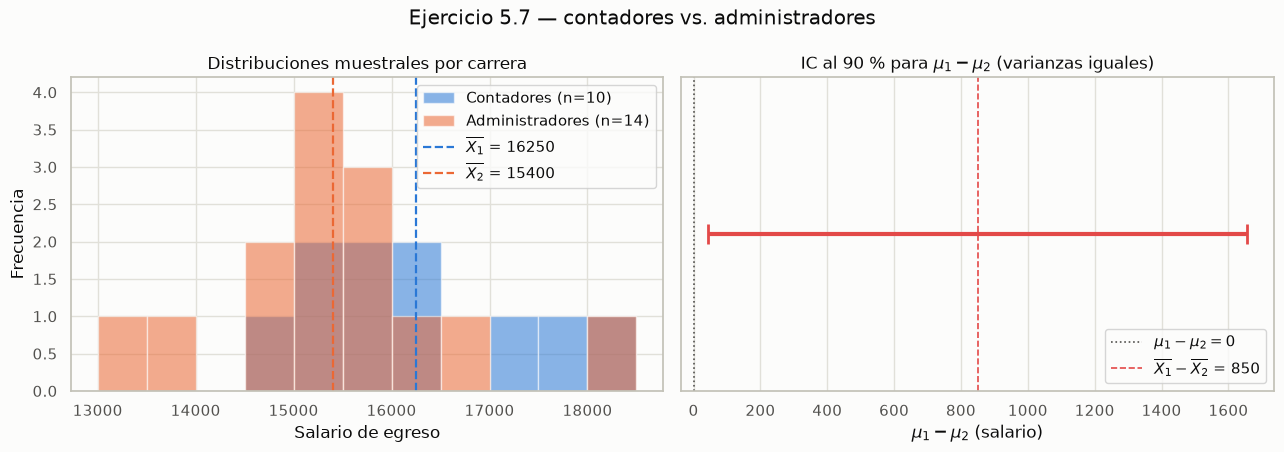

In [18]:
# Visualizacion: histogramas de cada grupo + IC de la diferencia en
# una segunda figura.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# Panel izquierdo: histogramas comparativos
ax = axes[0]
bins = np.arange(13000, 18501, 500)
ax.hist(
    contadores, bins=bins, alpha=0.55, color=COLOR_CONOCIDA,
    label=f"Contadores (n={n1})", edgecolor="white",
)
ax.hist(
    administradores, bins=bins, alpha=0.55, color=COLOR_DESCONOCIDA,
    label=f"Administradores (n={n2})", edgecolor="white",
)
ax.axvline(m1, color=COLOR_CONOCIDA, linestyle="--", linewidth=1.6,
           label=f"$\overline{{X_1}}$ = {m1:.0f}")
ax.axvline(m2, color=COLOR_DESCONOCIDA, linestyle="--", linewidth=1.6,
           label=f"$\overline{{X_2}}$ = {m2:.0f}")
ax.set_xlabel("Salario de egreso")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribuciones muestrales por carrera")
ax.legend(loc="upper right", frameon=True)

# Panel derecho: forest plot del IC para mu1 - mu2
ax = axes[1]
ax.hlines(
    y=0, xmin=li_e57, xmax=ls_e57, color=COLOR_HIGHLIGHT, linewidth=3,
)
ax.plot(
    [li_e57, ls_e57], [0, 0], "|",
    color=COLOR_HIGHLIGHT, markersize=14, markeredgewidth=2,
)
ax.axvline(0, color="#52514e", linestyle=":", linewidth=1.2,
           label="$\mu_1 - \mu_2 = 0$")
ax.axvline(diff_e57, color=COLOR_HIGHLIGHT, linestyle="--", linewidth=1.2,
           label=f"$\overline{{X_1}} - \overline{{X_2}}$ = {diff_e57:.0f}")
ax.set_yticks([])
ax.set_xlabel("$\mu_1 - \mu_2$ (salario)")
ax.set_title("IC al 90 % para $\mu_1 - \mu_2$ (varianzas iguales)")
ax.legend(loc="lower right", frameon=True)

fig.suptitle("Ejercicio 5.7 — contadores vs. administradores")
fig.tight_layout()
plt.show()

**Conclusión 5.7.** Con $n_1 = 10$, $\bar X_1 = 16250$, $s_1^2 \approx 1187\,222$ y $n_2 = 14$, $\bar X_2 = 15400$, $s_2^2 \approx 1352\,308$, la varianza combinada es $s_p^2 \approx 1284\,773$ ($s_p \approx 1133.48$). Para 22 grados de libertad, $t_{0.05, 22} \approx 1.7171$, y el margen es $1.7171 \cdot 1133.48 \cdot \sqrt{1/10 + 1/14} \approx 805.86$. Así,

$$
44.14 \leq \mu_1 - \mu_2 \leq 1655.86
$$

con 90 % de confianza. Puesto que el intervalo **no contiene al 0**, existe evidencia al 90 % de que los contadores tienen, en promedio, un salario de egreso mayor que los administradores (entre $\approx 44$ y $\approx 1656$ pesos más). El supuesto de varianzas iguales debe verificarse en la práctica (por ejemplo, con la prueba $F$ de igualdad de varianzas o con la prueba de Levene).

[Volver al índice](#indice)

<a id="conclusiones"></a>
## 8. Conclusiones

Los cuatro ejercicios ilustran cómo construir y comparar intervalos de confianza bajo distintos supuestos sobre la varianza poblacional.

**Tabla resumen.**

| Ejercicio | Caso | Nivel | Resultado |
|-----------|------|-------|-----------|
| 5.4 | $\sigma = 5$ (conocida) | 90 % | $(501.69,\, 505.81)$ |
| 5.4 | $\sigma = 5$ (conocida) | 95 % | $(501.30,\, 506.20)$ |
| 5.4 | $\sigma = 5$ (conocida) | 99 % | $(500.53,\, 506.97)$ |
| 5.5 | tamaño de muestra | 90 % | $n^* \approx 27.06$, $n_{\min} = 28$ |
| 5.6 | $\sigma$ desconocida ($s = 6.202$) | 90 % | $(501.03,\, 506.47)$ |
| 5.6 | $\sigma$ desconocida ($s = 6.202$) | 95 % | $(500.45,\, 507.05)$ |
| 5.6 | $\sigma$ desconocida ($s = 6.202$) | 99 % | $(499.18,\, 508.32)$ |
| 5.7 | $\mu_1 - \mu_2$ (var. iguales) | 90 % | $(44.14,\, 1655.86)$ |

**Puntos a recordar:**

1. Cuando $\sigma$ es **conocida**, el IC para $\mu$ se construye con $z_{\alpha/2}$ (cuantil de $N(0, 1)$).
2. Cuando $\sigma$ es **desconocida**, se sustituye por $s$ y se usa $t_{\alpha/2, n-1}$. Con $n$ moderado el cuantil $t$ es sustancialmente mayor que $z$, especialmente a niveles altos de confianza.
3. El **ancho** del IC es $2 \cdot z_{\alpha/2} \cdot \sigma / \sqrt{n}$ (o su análogo con $t$ y $s$). Para reducirlo a la mitad hay que **cuadruplicar** el tamaño de muestra.
4. El **tamaño de muestra** se despeja fijando un ancho o una probabilidad de cobertura y un valor (o estimación) de $\sigma$.
5. Para **dos medias**, con varianzas iguales se usa la varianza combinada $s_p^2$ y $t_{n_1 + n_2 - 2}$; el IC de la diferencia que no contiene al 0 es evidencia (al nivel correspondiente) de diferencia significativa.